# 02 — Khảo sát tham số tiền xử lý (Parameter Sweep)

**Mục tiêu:** So sánh 3 bộ tham số Gaussian Blur + CLAHE trên **cả 3 video** của đề tài:

1. `traffic_free_flow.mp4` — giao thông thông thoáng
2. `traffic_congested.mp4` — giao thông ùn tắc
3. `traffic_traffic_light.mp4` — giao thông tại đèn tín hiệu

Notebook tạo các ảnh **Side-by-Side trước/sau tiền xử lý**, giúp lựa chọn tham số phù hợp cho bước **trừ nền ở TV3**.

> Không sử dụng ROI trong notebook này. `src_pts`/BEV không cần thiết cho nhiệm vụ khảo sát tiền xử lý.

## 1. Import thư viện và kiểm tra thư mục dự án

In [2]:
import cv2
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
import sys

# Notebook được chạy từ thư mục gốc của project.
PROJECT_ROOT = Path.cwd()

# Nếu notebook được mở khi working directory đang ở notebooks/ thì tự lùi lên 1 cấp.
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT))

from modules.preprocessing import preprocess_frame

DATA_DIR = PROJECT_ROOT / "data" / "raw"
print("Project root:", PROJECT_ROOT)
print("Data dir    :", DATA_DIR)

Project root: C:\Users\Thommy31\Downloads\traffic-congestion-cv-main\traffic-congestion-cv-main
Data dir    : C:\Users\Thommy31\Downloads\traffic-congestion-cv-main\traffic-congestion-cv-main\data\raw


## 2. Khai báo 3 video và 3 bộ tham số

In [4]:
VIDEO_FILES = [
    "traffic_free_flow.mp4",
    "traffic_congested.mp4",
    "traffic_traffic_light.mp4",
]

# 3 cấu hình để khảo sát:
# A: Blur nhẹ + CLAHE nhẹ
# B: Cân bằng giữa khử nhiễu và tăng tương phản
# C: Blur mạnh + CLAHE mạnh
EXPERIMENTS = [
    {
        "name": "A - Nhẹ",
        "blur_ksize": (3, 3),
        "clip_limit": 1.0,
    },
    {
        "name": "B - Cân bằng",
        "blur_ksize": (5, 5),
        "clip_limit": 2.0,
    },
    {
        "name": "C - Mạnh",
        "blur_ksize": (7, 7),
        "clip_limit": 4.0,
    },
]

print("Videos:")
for v in VIDEO_FILES:
    print(" -", v)

print("\nExperiments:")
for e in EXPERIMENTS:
    print(
        f" - {e['name']}: "
        f"Gaussian={e['blur_ksize']}, "
        f"CLAHE clipLimit={e['clip_limit']}"
    )

Videos:
 - traffic_free_flow.mp4
 - traffic_congested.mp4
 - traffic_traffic_light.mp4

Experiments:
 - A - Nhẹ: Gaussian=(3, 3), CLAHE clipLimit=1.0
 - B - Cân bằng: Gaussian=(5, 5), CLAHE clipLimit=2.0
 - C - Mạnh: Gaussian=(7, 7), CLAHE clipLimit=4.0


## 3. Kiểm tra thông tin 3 video

In [5]:
video_info = []

for video_name in VIDEO_FILES:
    path = DATA_DIR / video_name
    cap = cv2.VideoCapture(str(path))

    if not cap.isOpened():
        print(f"[LỖI] Không mở được: {path}")
        continue

    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps = cap.get(cv2.CAP_PROP_FPS)
    frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    duration = frames / fps if fps else 0
    cap.release()

    video_info.append({
        "Video": video_name,
        "Width": width,
        "Height": height,
        "FPS": round(fps, 2),
        "Frames": frames,
        "Duration (s)": round(duration, 2),
    })

info_df = pd.DataFrame(video_info)
info_df

,Video,Width,Height,FPS,Frames,Duration (s)
0,traffic_free_flow.mp4,1920,1080,59.83,3640,60.84
1,traffic_congested.mp4,1920,1080,29.97,1397,46.61
2,traffic_traffic_light.mp4,1918,970,30.00,1743,58.10


## 4. Lấy một frame đại diện từ mỗi video

In [6]:
# Lấy frame tại khoảng 3 giây để tránh trường hợp frame đầu tiên chưa có phương tiện rõ ràng.
SAMPLE_TIME_SEC = 3.0

frames = {}

for video_name in VIDEO_FILES:
    path = DATA_DIR / video_name
    cap = cv2.VideoCapture(str(path))
    cap.set(cv2.CAP_PROP_POS_MSEC, SAMPLE_TIME_SEC * 1000)
    ret, frame = cap.read()
    cap.release()

    if not ret:
        print(f"[LỖI] Không đọc được frame từ {video_name}")
        continue

    frames[video_name] = frame
    print(f"{video_name}: frame shape = {frame.shape}")

if len(frames) != len(VIDEO_FILES):
    raise RuntimeError("Có video không đọc được frame. Kiểm tra lại data/raw/.")

traffic_free_flow.mp4: frame shape = (1080, 1920, 3)
traffic_congested.mp4: frame shape = (1080, 1920, 3)
traffic_traffic_light.mp4: frame shape = (970, 1918, 3)


## 5. Hiển thị ảnh gốc của cả 3 video

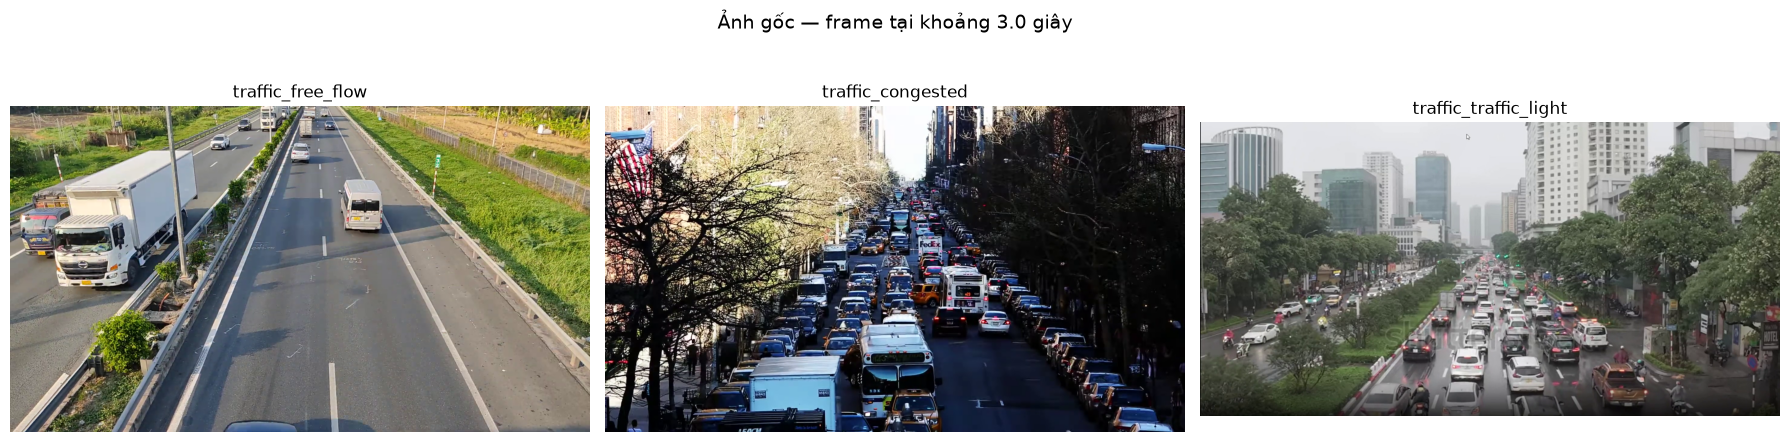

In [7]:
plt.figure(figsize=(18, 5))

for i, video_name in enumerate(VIDEO_FILES, start=1):
    frame_rgb = cv2.cvtColor(frames[video_name], cv2.COLOR_BGR2RGB)
    plt.subplot(1, 3, i)
    plt.imshow(frame_rgb)
    plt.title(video_name.replace(".mp4", ""))
    plt.axis("off")

plt.suptitle(f"Ảnh gốc — frame tại khoảng {SAMPLE_TIME_SEC} giây", fontsize=14)
plt.tight_layout()
plt.show()

## 6. Chạy Parameter Sweep cho cả 3 video

In [8]:
results = {}

for video_name, frame in frames.items():
    results[video_name] = {
        "original": frame,
        "processed": {}
    }

    for exp in EXPERIMENTS:
        processed = preprocess_frame(
            frame,
            clip_limit=exp["clip_limit"],
            tile_grid_size=(8, 8),
            blur_ksize=exp["blur_ksize"],
        )
        results[video_name]["processed"][exp["name"]] = processed

print("Đã hoàn thành:", len(VIDEO_FILES), "video ×", len(EXPERIMENTS), "bộ tham số")

Đã hoàn thành: 3 video × 3 bộ tham số


## 7. Side-by-Side — từng video: ảnh gốc và 3 kết quả

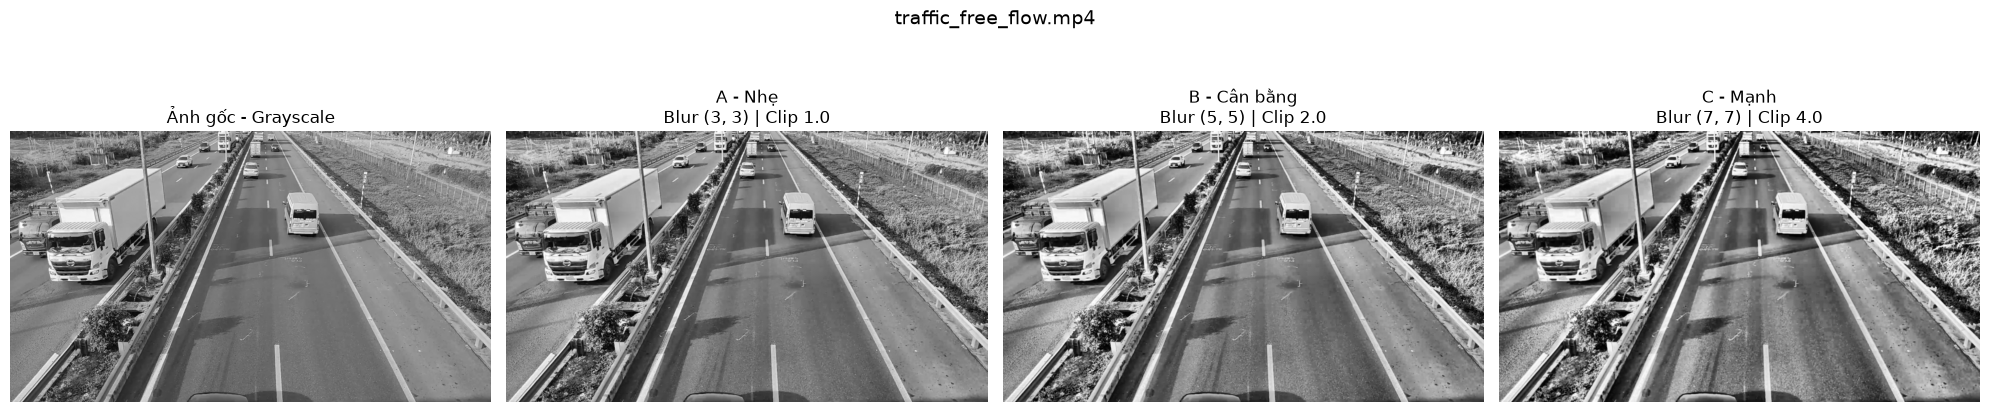

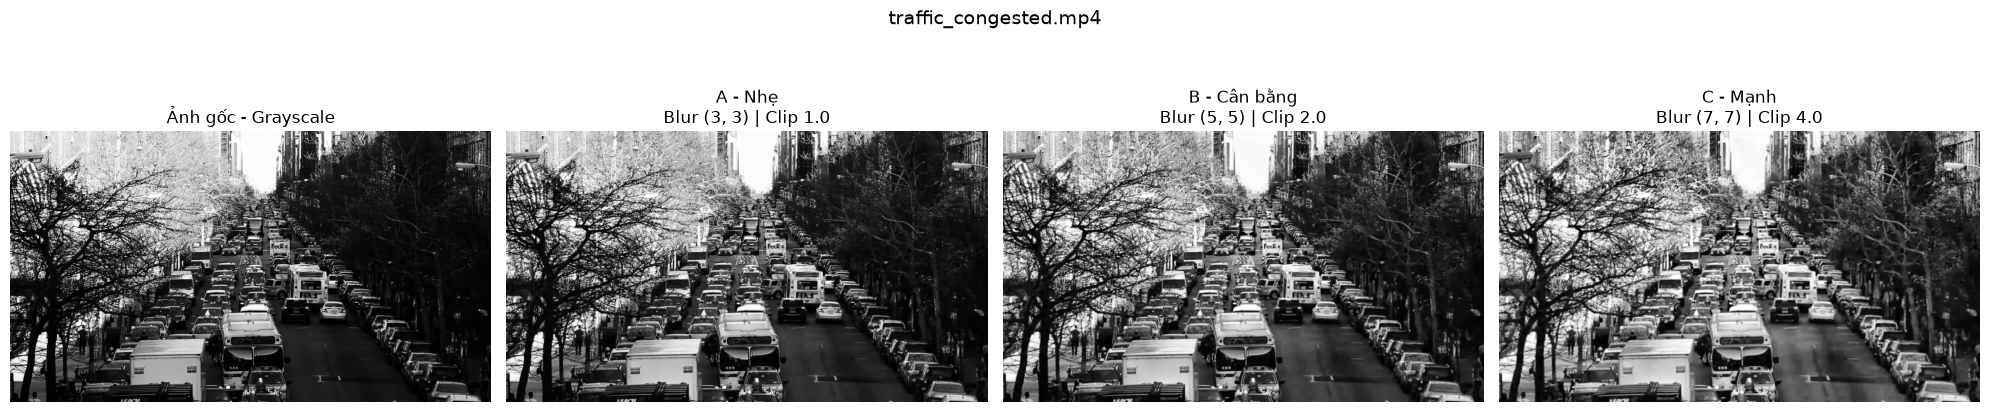

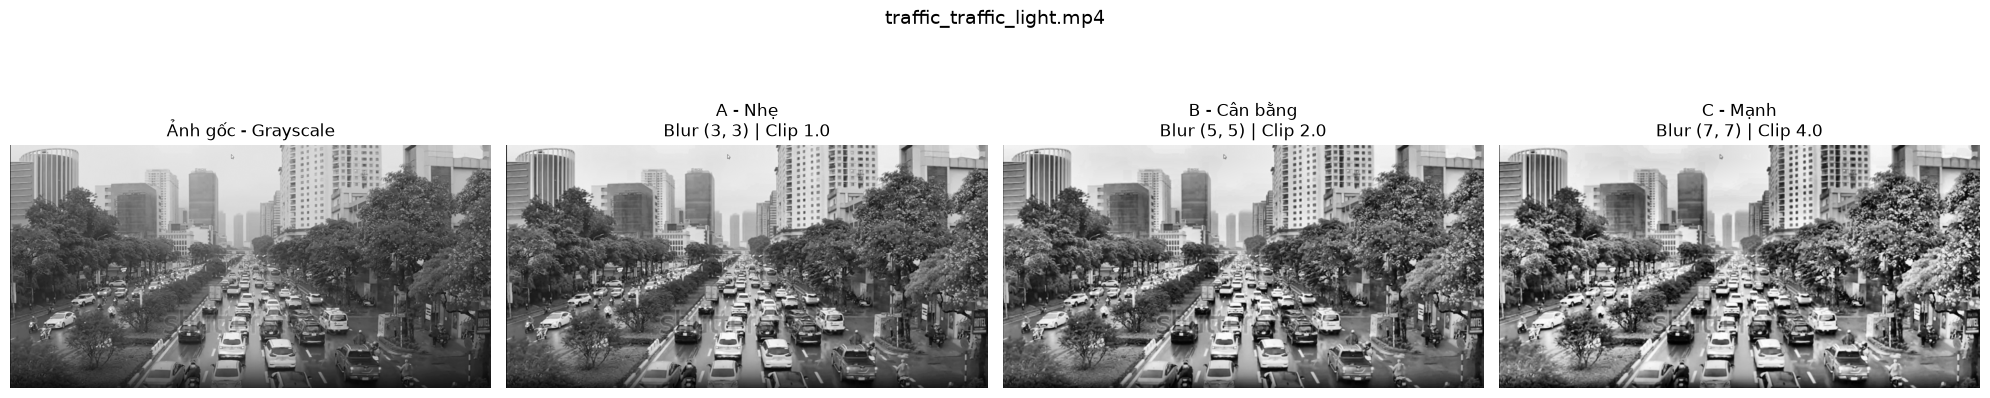

In [10]:
for video_name in VIDEO_FILES:

    original_gray = cv2.cvtColor(
        results[video_name]["original"],
        cv2.COLOR_BGR2GRAY
    )

    plt.figure(figsize=(20, 5))

    # =========================
    # ẢNH GỐC
    # =========================
    plt.subplot(1, 4, 1)

    plt.imshow(
        original_gray,
        cmap="gray"
    )

    plt.title("Ảnh gốc - Grayscale")
    plt.axis("off")

    # =========================
    # 3 THÍ NGHIỆM
    # =========================
    for i, exp in enumerate(EXPERIMENTS, start=2):

        plt.subplot(1, 4, i)

        plt.imshow(
            results[video_name]["processed"][exp["name"]],
            cmap="gray"
        )

        plt.title(
            f"{exp['name']}\n"
            f"Blur {exp['blur_ksize']} | "
            f"Clip {exp['clip_limit']}"
        )

        plt.axis("off")

    plt.suptitle(
        video_name,
        fontsize=14
    )

    plt.tight_layout()
    plt.show()

## 8. So sánh 3 video trong cùng một bảng hình

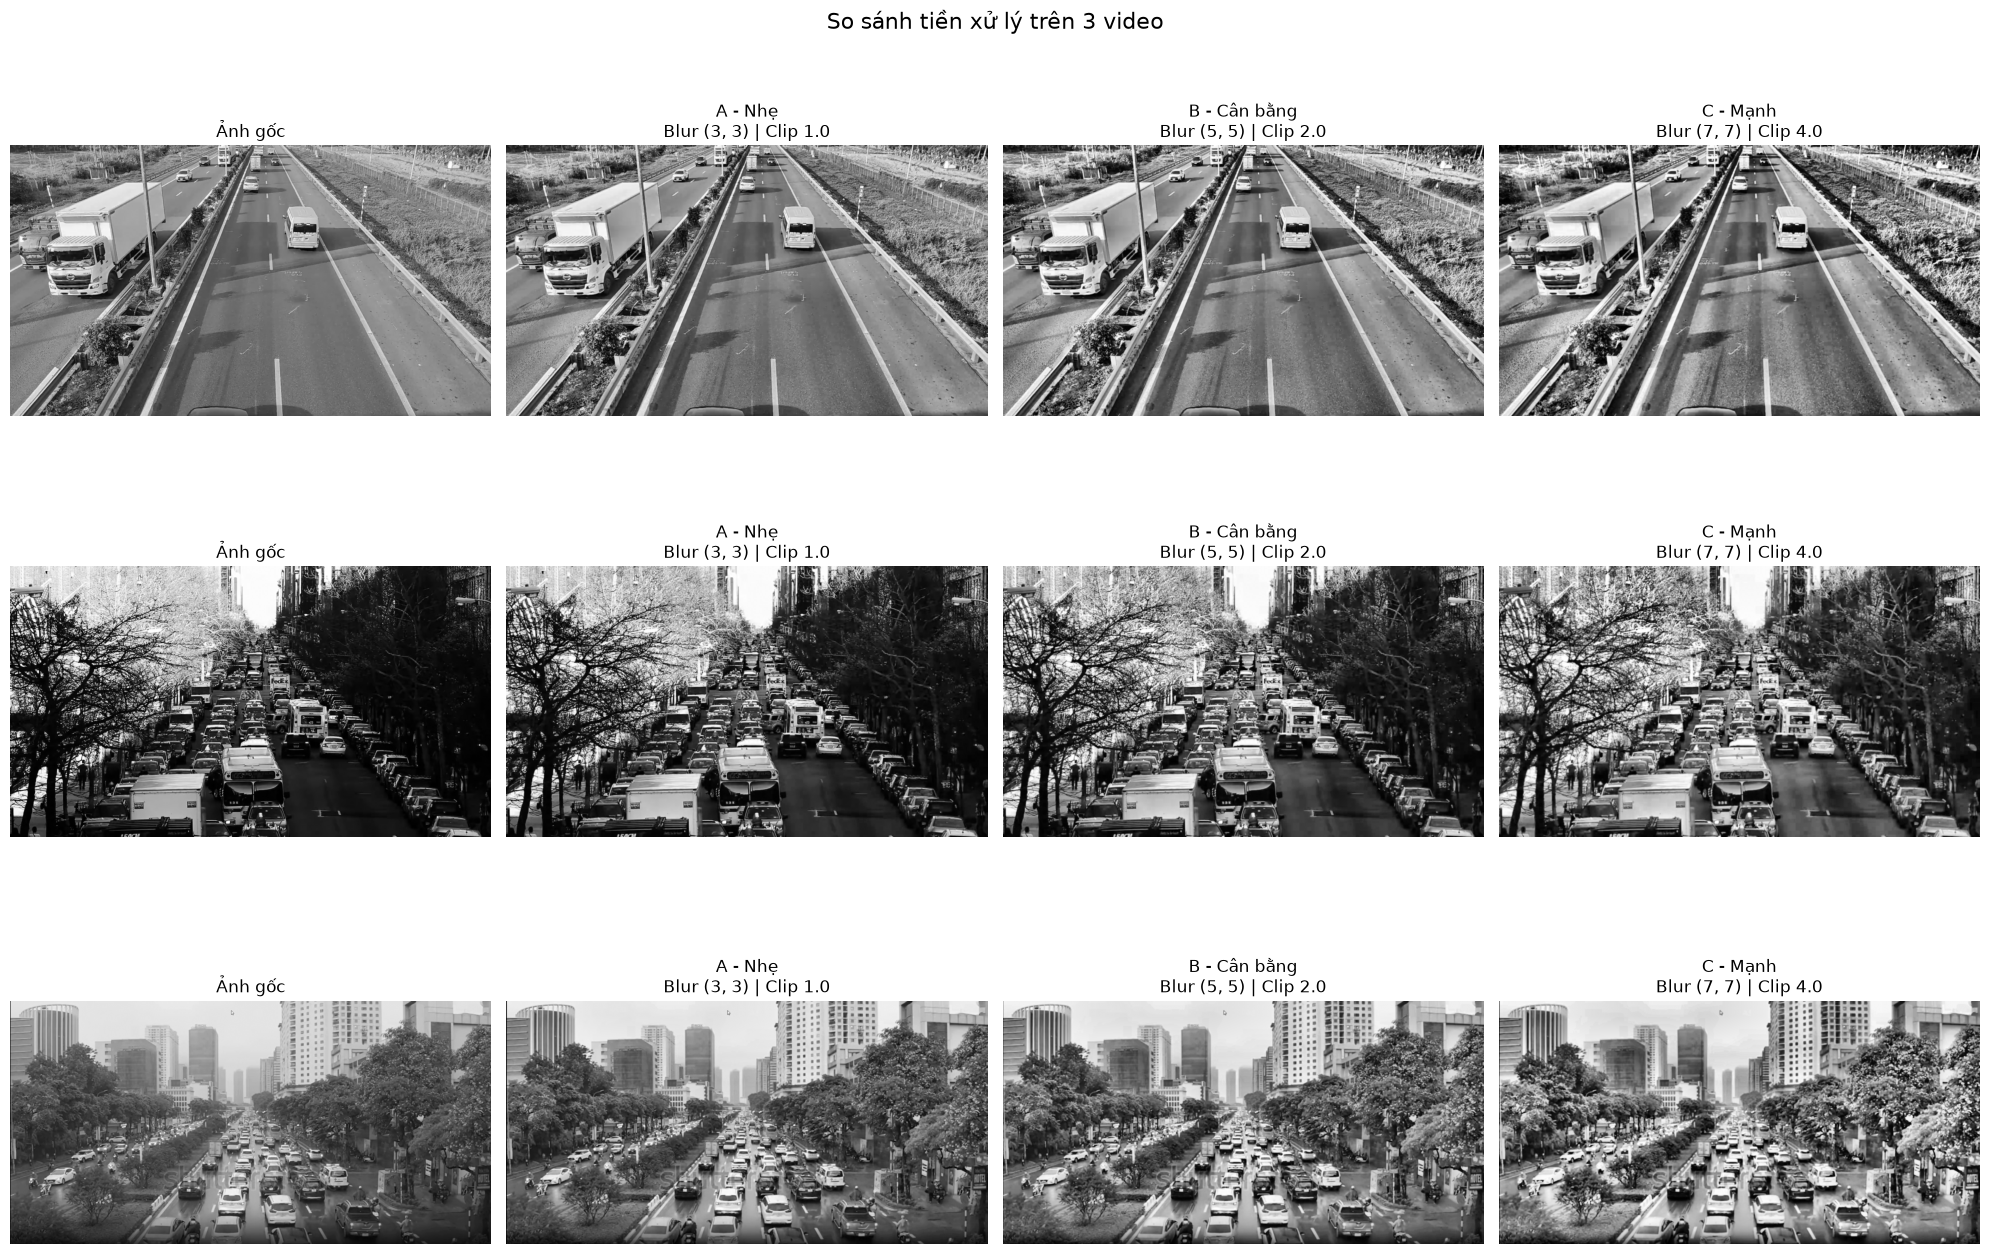

In [12]:
# Mỗi hàng = một video; mỗi cột = một cấu hình.
# Cột đầu tiên là ảnh gốc grayscale.

fig, axes = plt.subplots(
    nrows=len(VIDEO_FILES),
    ncols=4,
    figsize=(20, 14)
)

for row, video_name in enumerate(VIDEO_FILES):

    original_gray = cv2.cvtColor(
        results[video_name]["original"],
        cv2.COLOR_BGR2GRAY
    )

    # =========================
    # CỘT 1: ẢNH GỐC
    # =========================
    axes[row, 0].imshow(
        original_gray,
        cmap="gray"
    )

    axes[row, 0].set_title("Ảnh gốc")
    axes[row, 0].axis("off")

    # =========================
    # CỘT 2-4: 3 CẤU HÌNH
    # =========================
    for col, exp in enumerate(EXPERIMENTS, start=1):

        axes[row, col].imshow(
            results[video_name]["processed"][exp["name"]],
            cmap="gray"
        )

        axes[row, col].set_title(
            f"{exp['name']}\n"
            f"Blur {exp['blur_ksize']} | Clip {exp['clip_limit']}"
        )

        axes[row, col].axis("off")

    # Tên video ở bên trái
    axes[row, 0].set_ylabel(
        video_name.replace("traffic_", "").replace(".mp4", ""),
        fontsize=12
    )

plt.suptitle(
    "So sánh tiền xử lý trên 3 video",
    fontsize=16
)

plt.tight_layout()
plt.show()

## 9. Lưu hình Side-by-Side để đưa vào báo cáo

In [16]:
OUTPUT_DIR = PROJECT_ROOT / "data" / "processed" / "preprocessing_sweep"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

for video_name in VIDEO_FILES:

    original_gray = cv2.cvtColor(
        results[video_name]["original"],
        cv2.COLOR_BGR2GRAY
    )

    fig = plt.figure(figsize=(20, 5))

    # =========================
    # ẢNH GỐC
    # =========================
    plt.subplot(1, 4, 1)

    plt.imshow(
        original_gray,
        cmap="gray"
    )

    plt.title("Ảnh gốc")
    plt.axis("off")

    # =========================
    # 3 CẤU HÌNH
    # =========================
    for i, exp in enumerate(EXPERIMENTS, start=2):

        plt.subplot(1, 4, i)

        plt.imshow(
            results[video_name]["processed"][exp["name"]],
            cmap="gray"
        )

        plt.title(
            f"{exp['name']}\n"
            f"Blur {exp['blur_ksize']} | Clip {exp['clip_limit']}"
        )

        plt.axis("off")

    # =========================
    # TIÊU ĐỀ
    # =========================
    plt.suptitle(
        video_name,
        fontsize=14
    )

    plt.tight_layout()

    # =========================
    # LƯU ẢNH
    # =========================
    output_path = (
        OUTPUT_DIR /
        f"{video_name.replace('.mp4', '')}_comparison.png"
    )

    plt.savefig(
        output_path,
        dpi=200,
        bbox_inches="tight"
    )

    plt.close(fig)

    print("Đã lưu:", output_path)

Đã lưu: C:\Users\Thommy31\Downloads\traffic-congestion-cv-main\traffic-congestion-cv-main\data\processed\preprocessing_sweep\traffic_free_flow_comparison.png
Đã lưu: C:\Users\Thommy31\Downloads\traffic-congestion-cv-main\traffic-congestion-cv-main\data\processed\preprocessing_sweep\traffic_congested_comparison.png
Đã lưu: C:\Users\Thommy31\Downloads\traffic-congestion-cv-main\traffic-congestion-cv-main\data\processed\preprocessing_sweep\traffic_traffic_light_comparison.png


## 10. Bảng tham số và kết luận đề xuất

In [15]:
parameter_df = pd.DataFrame([
    {
        "Thí nghiệm": e["name"],
        "Gaussian Blur": str(e["blur_ksize"]),
        "CLAHE clipLimit": e["clip_limit"],
        "Đánh giá": (
            "Giữ nhiều chi tiết, xử lý nhẹ"
            if e["name"].startswith("A") else
            "Cân bằng giảm nhiễu và giữ biên"
            if e["name"].startswith("B") else
            "Làm mượt/tăng tương phản mạnh, có thể mất chi tiết"
        )
    }
    for e in EXPERIMENTS
])

parameter_df

,Thí nghiệm,Gaussian Blur,CLAHE clipLimit,Đánh giá
0,A - Nhẹ,"(3, 3)",1.0,"Giữ nhiều chi tiết, xử lý nhẹ"
1,B - Cân bằng,"(5, 5)",2.0,Cân bằng giảm nhiễu và giữ biên
2,C - Mạnh,"(7, 7)",4.0,"Làm mượt/tăng tương phản mạnh, có thể mất chi ..."


### Nhận xét dùng cho Lab Report

- **Thí nghiệm A — Gaussian `(3,3)`, clipLimit `1.0`:** làm mượt nhẹ nên giữ được nhiều chi tiết nhỏ, nhưng khả năng giảm nhiễu còn hạn chế.
- **Thí nghiệm B — Gaussian `(5,5)`, clipLimit `2.0`:** tạo sự cân bằng giữa khử nhiễu, giữ biên phương tiện và tăng tương phản. Đây là cấu hình **đề xuất**.
- **Thí nghiệm C — Gaussian `(7,7)`, clipLimit `4.0`:** làm mượt và tăng tương phản mạnh hơn; có thể làm mất một số chi tiết biên và CLAHE có thể làm nổi nhiễu ở vùng phức tạp.

**Liên hệ với trừ nền ở TV3:** Gaussian Blur giúp giảm nhiễu và các thay đổi nhỏ của nền, từ đó hạn chế foreground giả. Tuy nhiên, kernel quá lớn có thể làm mờ biên phương tiện. CLAHE giúp tăng tương phản trong điều kiện ánh sáng không đồng đều, nhưng `clipLimit` quá cao có thể khuếch đại nhiễu và tạo thêm vùng foreground giả.

**Kết luận đề xuất:** chọn **Gaussian Blur `(5,5)` + CLAHE `clipLimit=2.0` + `tile_grid_size=(8,8)`** vì đây là điểm cân bằng hợp lý cho cả ba video và phù hợp để tiếp tục đánh giá bước trừ nền ở TV3.